<a href="https://colab.research.google.com/github/yorsyd/LearnData/blob/main/MK-DeepLearning/DL_Praktikum_7_Forecasting_using_LSTM_Praktikan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab DL 06 LSTM untuk Forecasting
Nama : Yoga Rusydi Arifin

NIM  : 2200018165

# **1. Pendahuluan**

**Warning: Sebelum melakukan praktikum ini, diharapkan Anda telah mempelajari teori tentang Long Short Term Memory (LSTM) terlebih dahulu**

Teori tentang LSTM dapat dibaca pada:
https://indoml.com/2018/04/13/pengenalan-long-short-term-memory-lstm-dan-gated-recurrent-unit-gru-rnn-bagian-2/




## Tujuan Praktikum
Tujuan dari praktikum ini adalah untuk mempelajari penggunakan Recurrent Neural Network (RNN) yaitu **Long Short Term Memory (LSTM)** untuk melakukan prediksi pada data yang bersifat *time-series* (data dengan fitur waktu berturutan).

LSTM dapat mengekstraksi interaksi pada data yang bersifat *sequential* (berupa sequence/urutan).

Dataset yang akan digunakan adalah *airline-passangers.csv*

Dataset airline-passangers memiliki dua fitur yaitu bulan dan jumlah penumpang *airline* (*passanger*).
Jumlah data pada dataset ini adalah 145 data.

Pada praktikum ini akan dibuat sebuah model untuk memprediksi jumlah penumpang *airline* (*passanger*) pada bulan selanjutnya.

Task yang akan dikerjakan tergolong ke dalam kasus Regresi pada data *time-series*.

## Langkah-langkah Praktikum

Langkah-langkah praktikum secara umum :


1.   Load Data yang akan digunakan
2.   Pre-process data (normalisasi)
1.   Split data training dan data test
1.   Ubah data ke dalam bentuk time-series
2.   Training model dengan data training
1.   Test model dengan data test
2.   Lakukan prediksi dengan data baru







Berikut ini adalah tampilan isi dari airline-passangers.csv

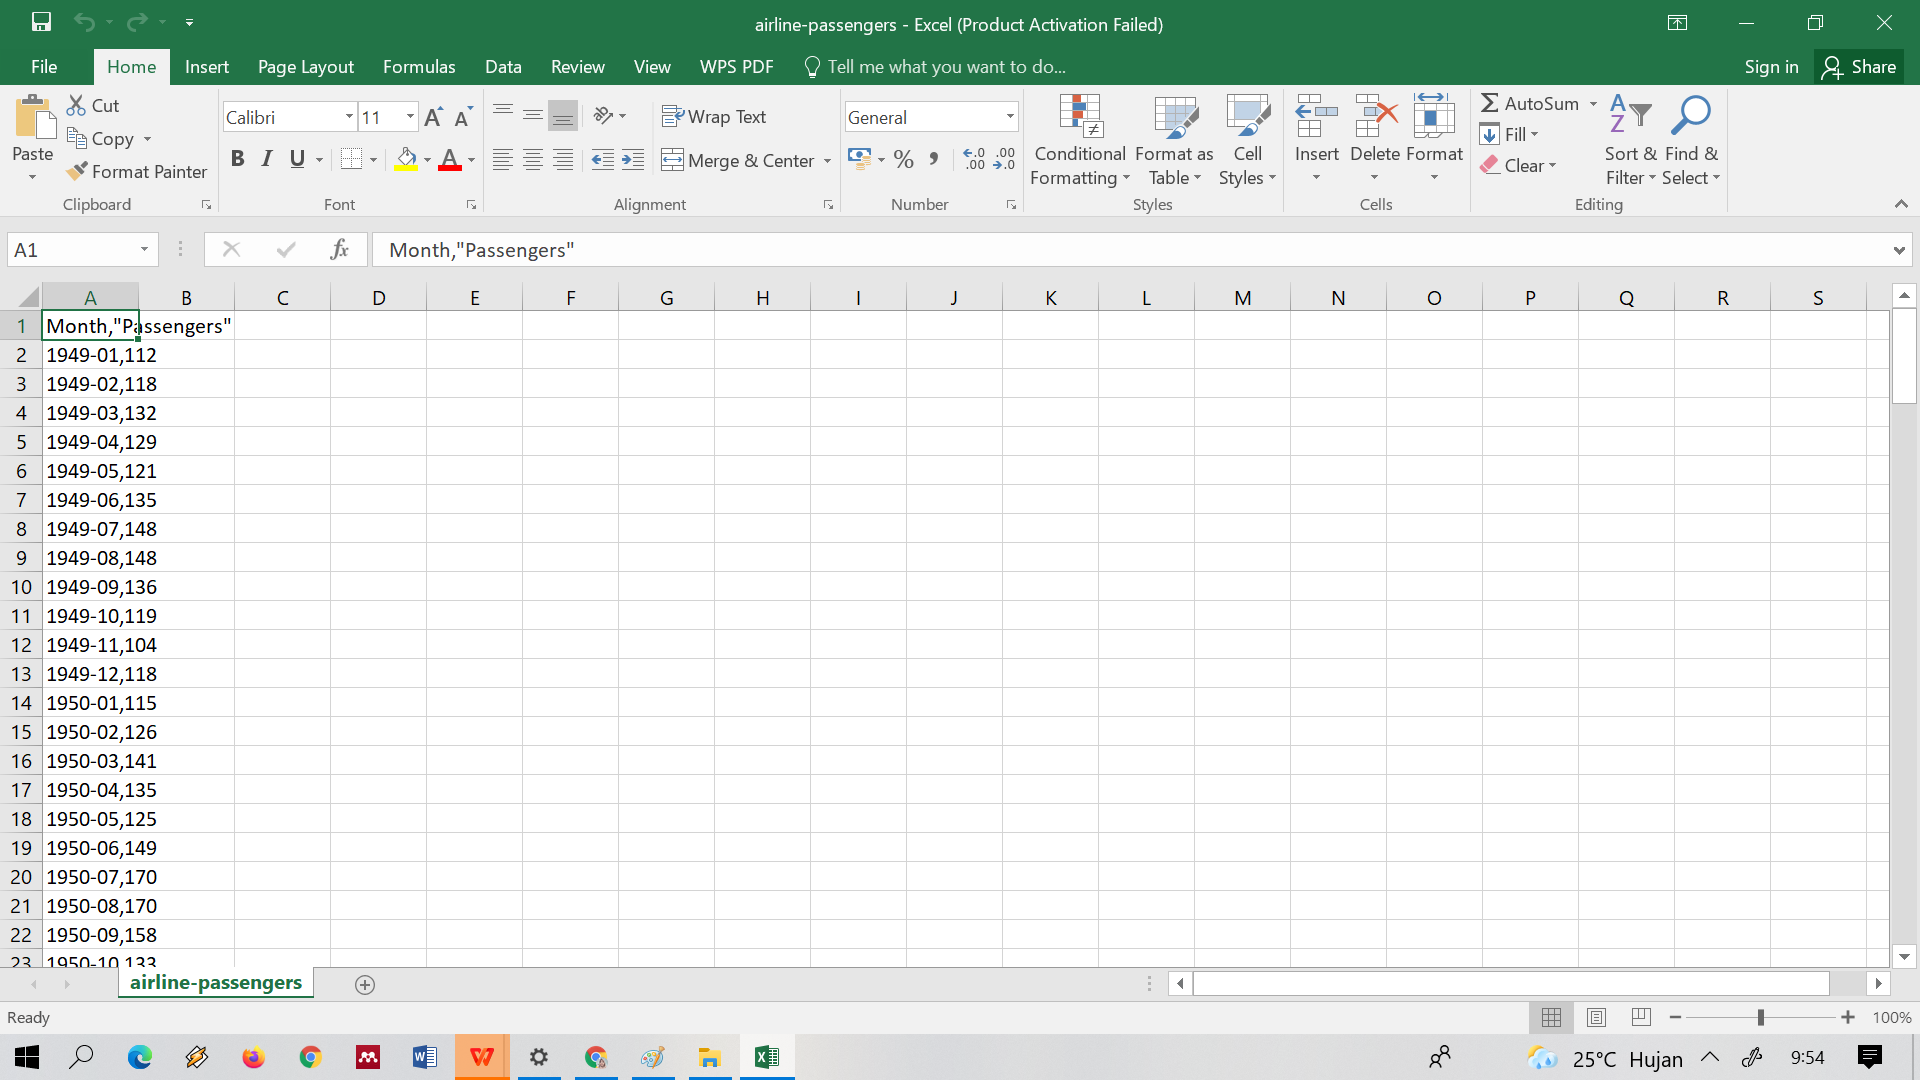

# **2. Mounting Google Drive**

In [1]:
from google.colab import drive

# mounting dataset dari gdrive
drive.mount('/content/gdrive', force_remount=True)

# lokasi dataset - ubah sesuai dengan lokasi anda mengupload folder datanya
root_path = 'gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/'

# opsional - tampilkan info lokasi dataset
print("Path root:", root_path)

Mounted at /content/gdrive
Path root: gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/


# **3**. **Import Library yang Akan Digunakan**

In [2]:
# import library yang akan digunakan
import numpy
import math

# import library tensorflow untuk implementasi Deep Learning
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# **4. Baca dan Visualisasi Dataset**

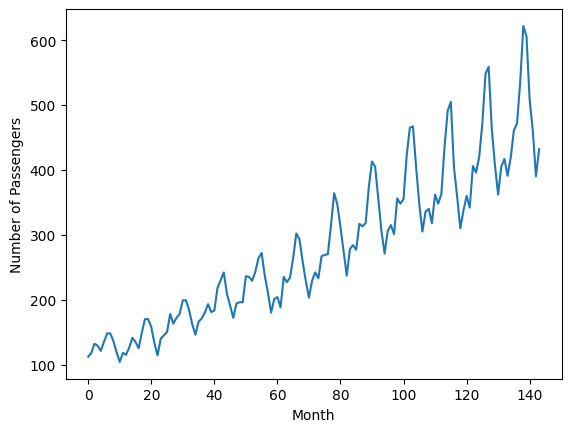

In [3]:
# load data dan lakukan plotting untuk melihat kondisi data
import pandas
import matplotlib.pyplot as plt
import os

datapath = os.path.join(root_path, 'airline-passengers.csv')
dataframe = pandas.read_csv(datapath, usecols=[1], engine='python')
plt.plot(dataframe)
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.show()

Dari gambar plot di atas dapat kita lihat bahwa data penumpang airline (passanger) membentuk sebuah pola. Meskipun data naik turun apabila dilihat dalam scope waktu yang kecil, namun secara keseluruhan data cenderung naik dari bulan ke 1 sampai bulan ke 144.

In [4]:
# data diubah ke dalam format float
dataset_pre_norm = dataframe.values
dataset_pre_norm = dataset_pre_norm.astype('float32')

## **4.1. Normalisasi Data**

LSTM sangat sensitif dengan 'scale' dari data, terutama jika menggunakan fungsi aktivasi default (Sigmoid dan Tanh). Oleh karena itu kita perlu lakukan normalisasi data untuk membuat nilai data berada dalam range 0 sampai 1. Gunakan **MinMaxScaler** untuk melakukan normalisasi data.

In [5]:
# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset_pre_norm)

## **4.2. Split Data menjadi Data Training dan Data Test**

Selanjutnya yang akan kita lakukan adalah membagi data menjadi training set dan test set. Training set digunakan untuk membangun model, sedangkan test set digunakan untuk menguji performa model yang dibuat.

Dalam kasus ini karena data berjumlah 144, kita gunakan 100 untuk training dan sisanya untuk test.

In [6]:
# split into train and test sets
train_size = 100
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]
print(len(train), len(test))

100 44


Selanjutnya, data yang sudah kita miliki perlu kita ubah bentuknya untuk merepresentasikan data time-series. Dalam hal ini, kita akan menghapus fitur '***month***' pada data *airline-passangers* dan hanya akan menggunakan fitur jumlah passanger saja.

Kemudian, cara membuat data time-series adalah dengan membentuk *sequence* dari data jumlah *passanger* dalam *window* waktu yang tertentu, misalnya 1, 2, 3, atau 4.

Contoh: Jika kita pilih window = 1, maka setiap data terdiri dari dua nilai yaitu data ke-t dan data ke-t+1. Dalam hal ini nanti data ke-t+1 akan diprediksi dengan hanya menggunakan data ke-t.
Jika kita pilih window = 2, maka setiap data terdiri dari tiga nilai yaitu data ke t-1, data ke-t, dan data ke-t+1. Dalam hal ini nanti data ke-t+1 akan diprediksi dengan data ke t-1 dan data ke-t

Oleh karena itu, kita perlu membuat sebuah fungsi untuk mengkonstruksi (membangun) data time-series dari data *airline-passanger*.

# **5. Pembentukan (Konstruksi) Data Time-Series**

In [7]:
# fungsi untuk meng-convert array ke dalam bentuk matriks time-series
# dengan window=1, karena dengan window=1 maka variabel look_back = 1,
# karena data yang akan diambil hanya data ke t dan t+1
# var look_back menyimpan jumlah window yang akan kita gunakan
def create_dataset(dataset, look_back):
    dataX, dataY=[], []
    for i in range(len(dataset) - look_back):
        # perhatikan a akan looping mulai dari data pertama
        # dan naik ke satu data berikutnya
	    a = dataset[i]
	    dataX.append(a)
	    dataY.append(dataset[i + look_back])
    return numpy.array(dataX), numpy.array(dataY)

Untuk mempermudah pemahaman, berikut ini contoh HASIL jika fungsi create_dataset diaplikasikan pada dataset yang belum dinormalisasi.

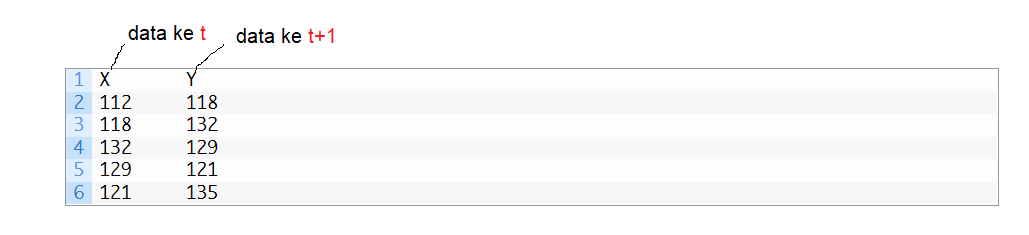

Jadi, fungsi create_dataset menghasilkan dataX yang berisi data ke-t, dan dataY yang berisi data ke-t+1

Mengapa kita perlu membentuk data seperti ini? Karena kita akan menggunakan dataX (data ke t) untuk melakukan prediksi nilai dataY (data ke t+1).

In [8]:
# panggil fungsi create_dataset pada data yang sudah ternormalisasi
# menghasilkan data X=t and Y=t+1
look_back = 1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

In [9]:
# tampilkan data pada trainX dan train Y
for i in range (len(trainX)):
    print(trainX[i], trainY[i])

print(len(trainX))
print(len(trainY))

[0.01544401] [0.02702703]
[0.02702703] [0.05405405]
[0.05405405] [0.04826255]
[0.04826255] [0.03281853]
[0.03281853] [0.05984557]
[0.05984557] [0.08494207]
[0.08494207] [0.08494207]
[0.08494207] [0.06177607]
[0.06177607] [0.02895753]
[0.02895753] [0.]
[0.] [0.02702703]
[0.02702703] [0.02123553]
[0.02123553] [0.04247104]
[0.04247104] [0.07142857]
[0.07142857] [0.05984557]
[0.05984557] [0.04054055]
[0.04054055] [0.08687258]
[0.08687258] [0.12741312]
[0.12741312] [0.12741312]
[0.12741312] [0.10424709]
[0.10424709] [0.05598456]
[0.05598456] [0.01930502]
[0.01930502] [0.06949806]
[0.06949806] [0.07915059]
[0.07915059] [0.08880308]
[0.08880308] [0.14285713]
[0.14285713] [0.11389962]
[0.11389962] [0.13127413]
[0.13127413] [0.14285713]
[0.14285713] [0.18339768]
[0.18339768] [0.18339768]
[0.18339768] [0.15444016]
[0.15444016] [0.11196911]
[0.11196911] [0.08108109]
[0.08108109] [0.1196911]
[0.1196911] [0.12934363]
[0.12934363] [0.14671814]
[0.14671814] [0.17181468]
[0.17181468] [0.14864865]
[0.1

Sampai di sini, apakah kalian paham mengapa jumlah data pada trainX dan trainY adalah 99 dan bukan 100?

# **6. Training Model LSTM**

Selanjutnya, yang akan kita lakukan adalah kita membangun model dengan LSTM untuk memprediksi nilai trainY dengan menggunakan nilai trainX. Setelah model berhasil dibuat, kita akan memprediksi nilai testY dengan menggunakan testX.

LSTM menerima input data dalam struktur array yang spesifik yaitu: **[samples, time steps, features]**.

Saat ini data yang kita miliki berada dalam format **[samples, features]** dan kita berasumsi bahwa satu timestep untuk setiap sample.

Oleh karena itu, kita perlu melakukan transformasi pada data trainX (yang akan dipakai untuk mentraining model) dan  testX(yang akan dipakai sebagai input saat testing) dengan numpy.reshape().

In [10]:
# reshape input to be [samples, time steps, features]
trainX = numpy.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = numpy.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [11]:
# Cek hasil reshape dengan print
print(trainX)

[[[0.01544401]]

 [[0.02702703]]

 [[0.05405405]]

 [[0.04826255]]

 [[0.03281853]]

 [[0.05984557]]

 [[0.08494207]]

 [[0.08494207]]

 [[0.06177607]]

 [[0.02895753]]

 [[0.        ]]

 [[0.02702703]]

 [[0.02123553]]

 [[0.04247104]]

 [[0.07142857]]

 [[0.05984557]]

 [[0.04054055]]

 [[0.08687258]]

 [[0.12741312]]

 [[0.12741312]]

 [[0.10424709]]

 [[0.05598456]]

 [[0.01930502]]

 [[0.06949806]]

 [[0.07915059]]

 [[0.08880308]]

 [[0.14285713]]

 [[0.11389962]]

 [[0.13127413]]

 [[0.14285713]]

 [[0.18339768]]

 [[0.18339768]]

 [[0.15444016]]

 [[0.11196911]]

 [[0.08108109]]

 [[0.1196911 ]]

 [[0.12934363]]

 [[0.14671814]]

 [[0.17181468]]

 [[0.14864865]]

 [[0.15250966]]

 [[0.22007722]]

 [[0.24324325]]

 [[0.26640925]]

 [[0.2027027 ]]

 [[0.16795367]]

 [[0.13127413]]

 [[0.17374519]]

 [[0.17760617]]

 [[0.17760617]]

 [[0.25482625]]

 [[0.25289574]]

 [[0.24131274]]

 [[0.26833975]]

 [[0.3088803 ]]

 [[0.32432434]]

 [[0.25675675]]

 [[0.20656371]]

 [[0.14671814]

In [12]:
# Cek hasil reshape dengan print
print(testX)

[[[0.484556  ]]

 [[0.6138996 ]]

 [[0.6969112 ]]

 [[0.70077217]]

 [[0.57915056]]

 [[0.46911195]]

 [[0.38803086]]

 [[0.44787642]]

 [[0.45559844]]

 [[0.4131274 ]]

 [[0.4980695 ]]

 [[0.47104248]]

 [[0.49999997]]

 [[0.6389961 ]]

 [[0.7471043 ]]

 [[0.7741313 ]]

 [[0.57915056]]

 [[0.492278  ]]

 [[0.3976834 ]]

 [[0.44980696]]

 [[0.49420848]]

 [[0.45945945]]

 [[0.5830116 ]]

 [[0.5637065 ]]

 [[0.61003864]]

 [[0.71042466]]

 [[0.8571429 ]]

 [[0.8783784 ]]

 [[0.69305015]]

 [[0.5849421 ]]

 [[0.4980695 ]]

 [[0.58108103]]

 [[0.6042471 ]]

 [[0.554054  ]]

 [[0.60810804]]

 [[0.6891892 ]]

 [[0.71042466]]

 [[0.8320464 ]]

 [[1.        ]]

 [[0.96911204]]

 [[0.7799227 ]]

 [[0.6891892 ]]

 [[0.55212355]]]


In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint

# membangun model dengan LSTM
model = Sequential()
# LSTM dengan 1 input dan 1 time-step dan LSTM memiliki 4 hidden layer
model.add(LSTM(4, input_shape=(1, 1)))
# ouput prediksi memiliki 1 nilai saja
model.add(Dense(1))
model.compile(loss='mean_squared_error',
              optimizer='adam')

# menampilkan summary dari model yang dibuat
model.summary()

# simpan model yang mendapatkan akurasi validasi tertinggi
checkpoint_filepath = os.path.join(root_path, 'lab06_lstm_model.h5')
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='loss',
    verbose=1,
    mode='auto',
    save_best_only=True)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101 (404.00 B)

 Trainable params: 101 (404.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# epoch yang digunakan 100 dan batch_size = 1
history = model.fit(trainX,
            trainY,
            epochs=100,
            batch_size=1,
            callbacks=[model_checkpoint_callback],
            verbose=1)

Epoch 1/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0484
Epoch 1: loss improved from inf to 0.03883, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0483
Epoch 2/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0220
Epoch 2: loss improved from 0.03883 to 0.01724, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0219
Epoch 3/100
92/99 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0114
Epoch 3: loss improved from 0.01724 to 0.01322, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0115
Epoch 4/100
91/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0124
Epoch 4: loss improved from 0.01322 to 0.01206, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0124
Epoch 5/100
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0102
Epoch 5: loss improved from 0.01206 to 0.01111, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model.h5


...

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0021
Epoch 39/100
98/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016
Epoch 39: loss did not improve from 0.00206
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016
Epoch 40/100
90/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022
Epoch 40: loss did not improve from 0.00206
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0022
Epoch 41/100
92/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024
Epoch 41: loss improved from 0.00206 to 0.00206, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model.h5


99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0024
Epoch 42/100
92/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026
Epoch 42: loss did not improve from 0.00206
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0026
Epoch 43/100
96/99 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0021
Epoch 43: loss did not improve from 0.00206
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0021
Epoch 44/100
89/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0022
Epoch 44: loss did not improve from 0.00206
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022
Epoch 45/100
96/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022
Epoch 45: loss did not improve from 0.00206
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022
Epoch 46/100
91/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0019
Epoch 46: loss did not improve from 0.00206
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0019
Epoch 47/100
86/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018
Epoch 47: loss did not improve from 0.00206
99/99 ━━━━

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0018
Epoch 50/100
90/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023
Epoch 50: loss did not improve from 0.00203
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023
Epoch 51/100
90/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026
Epoch 51: loss did not improve from 0.00203
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0025
Epoch 52/100
85/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018
Epoch 52: loss did not improve from 0.00203
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019
Epoch 53/100
89/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023
Epoch 53: loss did not improve from 0.00203
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023
Epoch 54/100
86/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 54: loss did not improve from 0.00203
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 55/100
91/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023
Epoch 55: loss did not improve from 0.00203
99/99 ━━━━

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0024
Epoch 79/100
89/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 79: loss did not improve from 0.00202
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 80/100
92/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020
Epoch 80: loss did not improve from 0.00202
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0020
Epoch 81/100
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 81: loss did not improve from 0.00202
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 82/100
89/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023
Epoch 82: loss did not improve from 0.00202
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023
Epoch 83/100
85/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017
Epoch 83: loss did not improve from 0.00202
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017
Epoch 84/100
89/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026
Epoch 84: loss did not improve from 0.00202
99/99 ━━━━

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019
Epoch 96/100
89/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 96: loss did not improve from 0.00194
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0021
Epoch 97/100
87/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0017
Epoch 97: loss did not improve from 0.00194
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018
Epoch 98/100
88/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018
Epoch 98: loss did not improve from 0.00194
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0018
Epoch 99/100
87/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 99: loss did not improve from 0.00194
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0021
Epoch 100/100
90/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019
Epoch 100: loss did not improve from 0.00194
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019


## Menampilkan statistik pelatihan

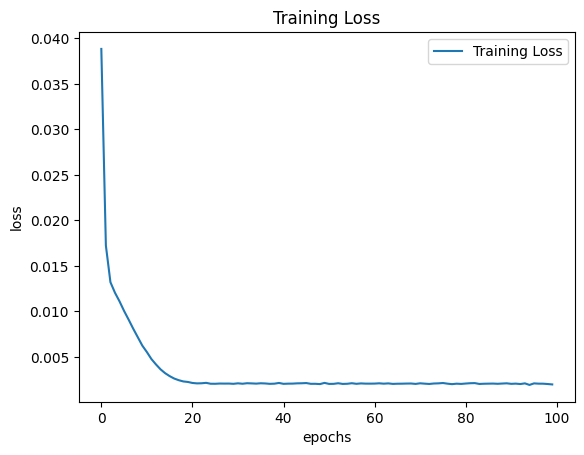

In [15]:
# ambil statistik pelatihan
loss = history.history['loss']

epochs_range = range(100)

# plot hasil loss pelatihan
plt.plot(epochs_range, loss, label='Training Loss')
plt.legend(loc='upper right')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.title('Training Loss')
plt.show()

# **7. Prediksi Data Test**

In [16]:
from tensorflow.keras.models import load_model

# load hasil pelatihan untuk di uji
trained_model = load_model(checkpoint_filepath)

# Prediksi pada test dataset
testPredict = trained_model.predict(testX)

print(testY)
print(testPredict)

# Perhitungan RMSE (Root Mean Square Error) pada hasil prediksi
testScore = math.sqrt(mean_squared_error(testY, testPredict))
print('Test Score: %.2f RMSE' % (testScore))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
[[0.6138996 ]
 [0.6969112 ]
 [0.70077217]
 [0.57915056]
 [0.46911195]
 [0.38803086]
 [0.44787642]
 [0.45559844]
 [0.4131274 ]
 [0.4980695 ]
 [0.47104248]
 [0.49999997]
 [0.6389961 ]
 [0.7471043 ]
 [0.7741313 ]
 [0.57915056]
 [0.492278  ]
 [0.3976834 ]
 [0.44980696]
 [0.49420848]
 [0.45945945]
 [0.5830116 ]
 [0.5637065 ]
 [0.61003864]
 [0.71042466]
 [0.8571429 ]
 [0.8783784 ]
 [0.69305015]
 [0.5849421 ]
 [0.4980695 ]
 [0.58108103]
 [0.6042471 ]
 [0.554054  ]
 [0.60810804]
 [0.6891892 ]
 [0.71042466]
 [0.8320464 ]
 [1.        ]
 [0.96911204]
 [0.7799227 ]
 [0.6891892 ]
 [0.55212355]
 [0.6332046 ]]
[[0.49366137]
 [0.60638434]
 [0.6728037 ]
 [0.6757736 ]
 [0.57715815]
 [0.47952807]
 [0.40339985]
 [0.4598892 ]
 [0.46705735]
 [0.42727903]
 [0.50591964]
 [0.4813018 ]
 [0.5076622 ]
 [0.62697697]
 [0.71057564]
 [0.73016334]
 [0.57715815]
 [0.5006787 ]
 [0.41261408]
 [0.46168405]
 [0.50242776]
 [0.47063008]
 [0.5804457 ]
 [0.5639097 ]
 [0.6031776 ]
 [0.6831

Hasil RMSE yang diperoleh adalah 0.1. Hal ini menunjukkan perbedaan antara hasil prediksi data ke t+1 dengan data t+1 sesungguhnya berkisar antara 0.1.  Menurut Anda apakah hasil ini sudah baik atau belum?

# **8. Visualisasi Hasil Prediksi pada Data Test dan Nilai Sebenarnya**

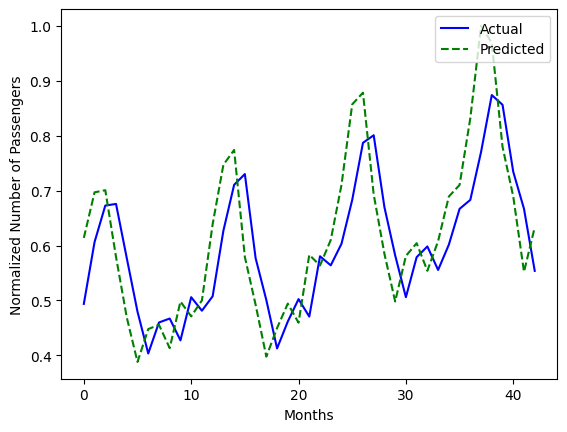

In [17]:
# plot hasil prediksi dengan garis warna biru
plt.plot(testPredict, 'b-', label='Actual')
# plot hasil prediksi dengan garis putus-putus warna hijau
plt.plot(testY, 'g--', label='Predicted')
plt.xlabel('Months')
plt.ylabel('Normalized Number of Passengers')
plt.legend(loc='upper right')
plt.show()

## **Windowing**

Pada bagian selanjutnya kita akan mencoba menggunakan ukuran window lebih besar dari 1.  Kita akan mencoba menggunakan window berukuran 4. Artinya kita akan memprediksi data ke-t+1 dengan menggunakan 4 data sebelumnya yaitu data ke-t, data ke t-1, data ke t-2, dan data ke t-3. Dalam hal ini kita perlu mengubah sedikit fungsi create_dataset sebagai berikut.

In [18]:
def create_dataset_window(dataset, look_back):
    dataX,dataY=[],[]

    for i in range(len(dataset)- look_back):
        a = []
        for j in range (0, look_back):
            a.append(dataset[i+j]) # a menyimpan data yang termasuk dalam window
        dataX.append(a)
        dataY.append(dataset[i + look_back])

    return numpy.array(dataX), numpy.array(dataY)

In [19]:
# panggil fungsi create_dataset pada data yang sudah ternormalisasi
# dengan look_back = 4
# menghasilkan data X=t and Y=t+1
look_back = 4
trainX_window4, trainY_window4 = create_dataset_window(train, look_back)
testX_window4, testY_window4 = create_dataset_window(test, look_back)

In [20]:
# tampilkan data yang telah dihasilkan
print(trainX_window4)
print(len(trainX_window4))

print(trainY_window4)
print(len(trainY_window4))

[[[0.01544401]
  [0.02702703]
  [0.05405405]
  [0.04826255]]

 [[0.02702703]
  [0.05405405]
  [0.04826255]
  [0.03281853]]

 [[0.05405405]
  [0.04826255]
  [0.03281853]
  [0.05984557]]

 [[0.04826255]
  [0.03281853]
  [0.05984557]
  [0.08494207]]

 [[0.03281853]
  [0.05984557]
  [0.08494207]
  [0.08494207]]

 [[0.05984557]
  [0.08494207]
  [0.08494207]
  [0.06177607]]

 [[0.08494207]
  [0.08494207]
  [0.06177607]
  [0.02895753]]

 [[0.08494207]
  [0.06177607]
  [0.02895753]
  [0.        ]]

 [[0.06177607]
  [0.02895753]
  [0.        ]
  [0.02702703]]

 [[0.02895753]
  [0.        ]
  [0.02702703]
  [0.02123553]]

 [[0.        ]
  [0.02702703]
  [0.02123553]
  [0.04247104]]

 [[0.02702703]
  [0.02123553]
  [0.04247104]
  [0.07142857]]

 [[0.02123553]
  [0.04247104]
  [0.07142857]
  [0.05984557]]

 [[0.04247104]
  [0.07142857]
  [0.05984557]
  [0.04054055]]

 [[0.07142857]
  [0.05984557]
  [0.04054055]
  [0.08687258]]

 [[0.05984557]
  [0.04054055]
  [0.08687258]
  [0.12741312]]

 [[0.040

Perhatikan pada trainX_window4 dari data yang kita hasilkan, data pertama terdiri dari data ke 1, 2, 3, 4.  Data kedua terdiri dari data ke 2,3,4,5. Data ketiga terdiri dari data ke 3,4,5,6. Sedangkan pada trainY_window4 data pertama adalah data ke 5, data kedua adalah data ke 6, data ketiga adalah data ke 7.

In [21]:
# reshape input to be [samples, time steps, features]
trainX_window4 = numpy.reshape(trainX_window4,
                               (trainX_window4.shape[0], 1, trainX_window4.shape[1]))
testX_window4 = numpy.reshape(testX_window4,
                              (testX_window4.shape[0], 1, testX_window4.shape[1]))

In [22]:
# membangun model dengan LSTM
model = Sequential()
#LSTM dengan 1 input dan 4 time-step dan LSTM memiliki 4 hidden layer
model.add(LSTM(4, input_shape=(1, 4)))
# ouput prediksi memiliki 1 nilai saja
model.add(Dense(1))
model.compile(loss='mean_squared_error',
              optimizer='adam')

# menampilkan summary dari model yang dibuat
model.summary()

# simpan model yang mendapatkan akurasi validasi tertinggi
checkpoint_filepath = os.path.join(root_path, 'lab06_lstm_model_rev.h5')
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False,
    monitor='loss',
    verbose=1,
    mode='auto',
    save_best_only=True)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 4)              │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 149 (596.00 B)

 Trainable params: 149 (596.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
# epoch yang digunakan 100 dan batch_size = 1
model.fit(trainX_window4,
          trainY_window4,
          epochs=100,
          batch_size=1,
          callbacks=[model_checkpoint_callback],
          verbose=1)

Epoch 1/100
91/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0512
Epoch 1: loss improved from inf to 0.04304, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_rev.h5


96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0507
Epoch 2/100
90/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0175
Epoch 2: loss improved from 0.04304 to 0.01607, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_rev.h5


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0174
Epoch 3/100
92/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0128
Epoch 3: loss improved from 0.01607 to 0.01047, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_rev.h5


96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0127
Epoch 4/100
89/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0080
Epoch 4: loss improved from 0.01047 to 0.00898, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_rev.h5


96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0081
Epoch 5/100
90/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0074
Epoch 5: loss improved from 0.00898 to 0.00783, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_rev.h5


...

96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023
Epoch 80/100
93/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019
Epoch 80: loss did not improve from 0.00197
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019
Epoch 81/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019
Epoch 81: loss did not improve from 0.00197
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0019
Epoch 82/100
85/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023
Epoch 82: loss improved from 0.00197 to 0.00196, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_rev.h5


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0023
Epoch 83/100
85/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 83: loss did not improve from 0.00196
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch 84/100
86/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 84: loss did not improve from 0.00196
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 85/100
87/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015
Epoch 85: loss did not improve from 0.00196
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0016
Epoch 86/100
91/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016
Epoch 86: loss did not improve from 0.00196
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0017
Epoch 87/100
88/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0018
Epoch 87: loss did not improve from 0.00196
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019
Epoch 88/100
92/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0022
Epoch 88: loss did not improve from 0.00196
96/96 ━━━━

96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0023
Epoch 91/100
85/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022
Epoch 91: loss did not improve from 0.00193
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0022
Epoch 92/100
91/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021
Epoch 92: loss did not improve from 0.00193
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021
Epoch 93/100
84/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0019
Epoch 93: loss did not improve from 0.00193
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0019
Epoch 94/100
87/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0020
Epoch 94: loss did not improve from 0.00193
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0020
Epoch 95/100
91/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024
Epoch 95: loss improved from 0.00193 to 0.00191, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_rev.h5


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0024
Epoch 96/100
89/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026
Epoch 96: loss did not improve from 0.00191
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0025
Epoch 97/100
90/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 97: loss improved from 0.00191 to 0.00191, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_rev.h5


96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch 98/100
90/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 98: loss did not improve from 0.00191
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch 99/100
85/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0023
Epoch 99: loss did not improve from 0.00191
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022
Epoch 100/100
90/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0022
Epoch 100: loss did not improve from 0.00191
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021


In [24]:
# load hasil pelatihan untuk di uji
trained_model = load_model(checkpoint_filepath)

# Prediksi pada test dataset
testPredict = trained_model.predict(testX_window4)

print(testY_window4)
print(testPredict)

# Perhitungan RMSE (Root Mean Square Error) pada hasil prediksi
testScore = math.sqrt(mean_squared_error(testY_window4, testPredict))
print('Test Score: %.2f RMSE' % (testScore))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
[[0.57915056]
 [0.46911195]
 [0.38803086]
 [0.44787642]
 [0.45559844]
 [0.4131274 ]
 [0.4980695 ]
 [0.47104248]
 [0.49999997]
 [0.6389961 ]
 [0.7471043 ]
 [0.7741313 ]
 [0.57915056]
 [0.492278  ]
 [0.3976834 ]
 [0.44980696]
 [0.49420848]
 [0.45945945]
 [0.5830116 ]
 [0.5637065 ]
 [0.61003864]
 [0.71042466]
 [0.8571429 ]
 [0.8783784 ]
 [0.69305015]
 [0.5849421 ]
 [0.4980695 ]
 [0.58108103]
 [0.6042471 ]
 [0.554054  ]
 [0.60810804]
 [0.6891892 ]
 [0.71042466]
 [0.8320464 ]
 [1.        ]
 [0.96911204]
 [0.7799227 ]
 [0.6891892 ]
 [0.55212355]
 [0.6332046 ]]
[[0.6152486 ]
 [0.47743586]
 [0.39804223]
 [0.3745853 ]
 [0.46719098]
 [0.4705522 ]
 [0.394006  ]
 [0.49812606]
 [0.4707877 ]
 [0.47379595]
 [0.6375626 ]
 [0.7097315 ]
 [0.6717865 ]
 [0.4447217 ]
 [0.4036973 ]
 [0.3923849 ]
 [0.4611257 ]
 [0.51282287]
 [0.43883082]
 [0.57050836]
 [0.54797554]
 [0.55521154]
 [0.6766367 ]
 [0.7827992 ]
 [0.7378994 ]
 [0.5030096 ]
 [0.4515341 ]
 [0.45842427]
 [0.5752

Perhatikan hasil RMSE 0.13, dengan menggunakan window berukuran 4 ternyata hasilnya tdak lebih baik dari pada menggunakan window berukuran 1 (RMSE 0.1). Anda dapat bereksperimen dengan mengganti epoch yang lebih tinggi.

# **POST TEST**

Dengan menggunakan dataset yang sama (*airline_passangers.csv*) modifikasi lah fungsi create_dataset_window sehingga menghasilkan pola data sebagai berikut:

X : [data t-4, data t-2,  data t]

Y : [data t+2]

Artinya untuk memprediksi data t+2 kita gunakan data t-4, data t-2, dan data t.  Lalu lakukan prediksi dengan LSTM yang memiliki jumlah hidden layer 5. Gunakan epoch 100 dan batch size 1. Hitunglah hasil RMSE nya!

In [25]:
# Cek logika aja sih
look_back_indices_to_use = [4, 2, 0]
for i in range(4, len(dataset) - 2):
  for j in look_back_indices_to_use:
    print([i - j])
  print(i+2)

[0]
[2]
[4]
6
[1]
[3]
[5]
7
[2]
[4]
[6]
8
[3]
[5]
[7]
9
[4]
[6]
[8]
10
[5]
[7]
[9]
11
[6]
[8]
[10]
12
[7]
[9]
[11]
13
[8]
[10]
[12]
14
[9]
[11]
[13]
15
[10]
[12]
[14]
16
[11]
[13]
[15]
17
[12]
[14]
[16]
18
[13]
[15]
[17]
19
[14]
[16]
[18]
20
[15]
[17]
[19]
21
[16]
[18]
[20]
22
[17]
[19]
[21]
23
[18]
[20]
[22]
24
[19]
[21]
[23]
25
[20]
[22]
[24]
26
[21]
[23]
[25]
27
[22]
[24]
[26]
28
[23]
[25]
[27]
29
[24]
[26]
[28]
30
[25]
[27]
[29]
31
[26]
[28]
[30]
32
[27]
[29]
[31]
33
[28]
[30]
[32]
34
[29]
[31]
[33]
35
[30]
[32]
[34]
36
[31]
[33]
[35]
37
[32]
[34]
[36]
38
[33]
[35]
[37]
39
[34]
[36]
[38]
40
[35]
[37]
[39]
41
[36]
[38]
[40]
42
[37]
[39]
[41]
43
[38]
[40]
[42]
44
[39]
[41]
[43]
45
[40]
[42]
[44]
46
[41]
[43]
[45]
47
[42]
[44]
[46]
48
[43]
[45]
[47]
49
[44]
[46]
[48]
50
[45]
[47]
[49]
51
[46]
[48]
[50]
52
[47]
[49]
[51]
53
[48]
[50]
[52]
54
[49]
[51]
[53]
55
[50]
[52]
[54]
56
[51]
[53]
[55]
57
[52]
[54]
[56]
58
[53]
[55]
[57]
59
[54]
[56]
[58]
60
[55]
[57]
[59]
61
[56]
[58]
[60]
62
[5

## Membuat fungsi generate dataset
Hal ini dilakukan sesuai dengan ketentuan di atas

In [26]:
def create_dataset_post_window(dataset, look_back_indices):
    dataX, dataY = [], []
    max_look_back = max(look_back_indices)

    for i in range(max_look_back, len(dataset) - 2):
        x_sequence = []
        for j in look_back_indices: # t-4 -- t
            x_sequence.append(dataset[i - j])
        dataX.append(x_sequence)
        dataY.append(dataset[i + 2]) # t+2

    return numpy.array(dataX), numpy.array(dataY)

## Generate dataset

In [27]:
look_back_indices_to_use = [4, 2, 0]
trainX_post, trainY_post = create_dataset_post_window(train, look_back_indices_to_use)
testX_post, testY_post = create_dataset_post_window(test, look_back_indices_to_use)

In [28]:
# tampilkan data yang telah dihasilkan
print(trainX_post)
print('Banyak data latih: ',len(trainX_post))
print('='*30)

print(trainY_post)
print('Banyak data label: ',len(trainY_post))

[[[0.01544401]
  [0.05405405]
  [0.03281853]]

 [[0.02702703]
  [0.04826255]
  [0.05984557]]

 [[0.05405405]
  [0.03281853]
  [0.08494207]]

 [[0.04826255]
  [0.05984557]
  [0.08494207]]

 [[0.03281853]
  [0.08494207]
  [0.06177607]]

 [[0.05984557]
  [0.08494207]
  [0.02895753]]

 [[0.08494207]
  [0.06177607]
  [0.        ]]

 [[0.08494207]
  [0.02895753]
  [0.02702703]]

 [[0.06177607]
  [0.        ]
  [0.02123553]]

 [[0.02895753]
  [0.02702703]
  [0.04247104]]

 [[0.        ]
  [0.02123553]
  [0.07142857]]

 [[0.02702703]
  [0.04247104]
  [0.05984557]]

 [[0.02123553]
  [0.07142857]
  [0.04054055]]

 [[0.04247104]
  [0.05984557]
  [0.08687258]]

 [[0.07142857]
  [0.04054055]
  [0.12741312]]

 [[0.05984557]
  [0.08687258]
  [0.12741312]]

 [[0.04054055]
  [0.12741312]
  [0.10424709]]

 [[0.08687258]
  [0.12741312]
  [0.05598456]]

 [[0.12741312]
  [0.10424709]
  [0.01930502]]

 [[0.12741312]
  [0.05598456]
  [0.06949806]]

 [[0.10424709]
  [0.01930502]
  [0.07915059]]

 [[0.05598456

Perhatikan pada trainX_post dari data yang dihasilkan, data pertama terdiri dari data ke 0, 2, 4.  Data kedua terdiri dari data ke 1, 3, 5. Data ketiga terdiri dari data ke 2, 4, 6. Sedangkan pada trainY_post data pertama adalah data ke 6, data kedua adalah data ke 7, data ketiga adalah data ke 8.

In [29]:
# reshape input to be [samples, time steps, features]
trainX_post = numpy.reshape(trainX_post, (trainX_post.shape[0], 1, trainX_post.shape[1]))
testX_post = numpy.reshape(testX_post, (testX_post.shape[0], 1, testX_post.shape[1]))

## Membangun model dengan LSTM

In [30]:
model_post = Sequential()
#LSTM dengan 1 input dan 3 time-step dan LSTM memiliki 5 hidden layer
model_post.add(LSTM(5, input_shape=(1, 3)))
# ouput prediksi memiliki 1 nilai saja
model_post.add(Dense(1))
model_post.compile(loss='mean_squared_error',
              optimizer='adam')

model_post.summary()

# simpan model yang mendapatkan akurasi validasi tertinggi
checkpoint_filepath_post = os.path.join(root_path, 'lab06_lstm_model_post.h5')
model_checkpoint_callback_post = ModelCheckpoint(
    filepath=checkpoint_filepath_post,
    save_weights_only=False,
    monitor='loss',
    verbose=1,
    mode='auto',
    save_best_only=True)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5)              │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186 (744.00 B)

 Trainable params: 186 (744.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
# epoch yang digunakan 100 dan batch_size = 1
history_post = model_post.fit(trainX_post,
                              trainY_post,
                              epochs=100,
                              batch_size=1,
                              callbacks=[model_checkpoint_callback_post],
                              verbose=1)

Epoch 1/100
87/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0741
Epoch 1: loss improved from inf to 0.05440, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_post.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0726
Epoch 2/100
83/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0184
Epoch 2: loss improved from 0.05440 to 0.01963, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_post.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0186
Epoch 3/100
90/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0157
Epoch 3: loss improved from 0.01963 to 0.01397, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_post.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0156
Epoch 4/100
89/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0152
Epoch 4: loss improved from 0.01397 to 0.01200, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_post.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0150
Epoch 5/100
84/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0103
Epoch 5: loss improved from 0.01200 to 0.01046, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_post.h5


...

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0040
Epoch 54/100
91/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0042
Epoch 54: loss did not improve from 0.00450
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0042
Epoch 55/100
86/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045
Epoch 55: loss did not improve from 0.00450
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045
Epoch 56/100
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0045
Epoch 56: loss did not improve from 0.00450
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0045
Epoch 57/100
85/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038
Epoch 57: loss improved from 0.00450 to 0.00449, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_post.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0039
Epoch 58/100
88/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0038
Epoch 58: loss improved from 0.00449 to 0.00441, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_post.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0039
Epoch 59/100
89/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049
Epoch 59: loss improved from 0.00441 to 0.00435, saving model to gdrive/My Drive/Colab Notebooks/Deep Learning Labs/LabDL06 Data/lab06_lstm_model_post.h5


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0049
Epoch 60/100
85/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0031
Epoch 60: loss did not improve from 0.00435
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0033
Epoch 61/100
90/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0066
Epoch 61: loss did not improve from 0.00435
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0065
Epoch 62/100
90/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039
Epoch 62: loss did not improve from 0.00435
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039
Epoch 63/100
89/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0044
Epoch 63: loss did not improve from 0.00435
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0044
Epoch 64/100
87/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0052
Epoch 64: loss did not improve from 0.00435
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0052
Epoch 65/100
85/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0043
Epoch 65: loss did not improve from 0.00435
94/94 ━━━━

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0042
Epoch 75/100
82/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0054
Epoch 75: loss did not improve from 0.00428
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0053
Epoch 76/100
88/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0046
Epoch 76: loss did not improve from 0.00428
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0046
Epoch 77/100
89/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039
Epoch 77: loss did not improve from 0.00428
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0039
Epoch 78/100
84/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035
Epoch 78: loss did not improve from 0.00428
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036
Epoch 79/100
87/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036
Epoch 79: loss did not improve from 0.00428
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0036
Epoch 80/100
86/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0049
Epoch 80: loss did not improve from 0.00428
94/94 ━━━━

## Visualisasi dan evaluasi

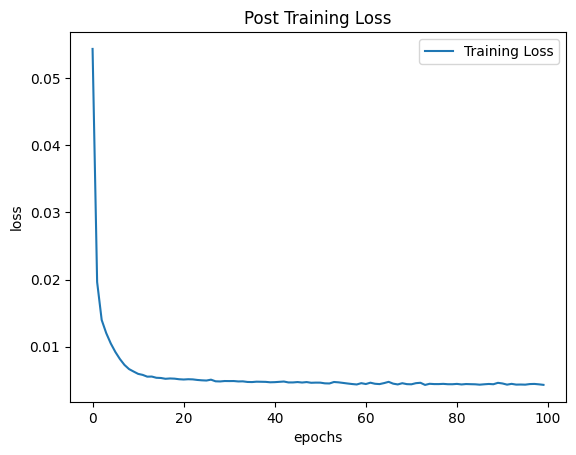

In [32]:
# Menampilkan statistik pelatihan
loss_post = history_post.history['loss']
epochs_range_post = range(100)

plt.plot(epochs_range_post, loss_post, label='Training Loss')
plt.legend(loc='upper right')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.title('Post Training Loss')
plt.show()

In [33]:
# load hasil pelatihan untuk di uji
trained_model_post = load_model(checkpoint_filepath_post)

# prediksi pada dataset
testPredict_post = trained_model_post.predict(testX_post)

print("post TestY:")
print(testY_post)
print("post Test Predict:")
print(testPredict_post)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
post TestY:
[[0.38803086]
 [0.44787642]
 [0.45559844]
 [0.4131274 ]
 [0.4980695 ]
 [0.47104248]
 [0.49999997]
 [0.6389961 ]
 [0.7471043 ]
 [0.7741313 ]
 [0.57915056]
 [0.492278  ]
 [0.3976834 ]
 [0.44980696]
 [0.49420848]
 [0.45945945]
 [0.5830116 ]
 [0.5637065 ]
 [0.61003864]
 [0.71042466]
 [0.8571429 ]
 [0.8783784 ]
 [0.69305015]
 [0.5849421 ]
 [0.4980695 ]
 [0.58108103]
 [0.6042471 ]
 [0.554054  ]
 [0.60810804]
 [0.6891892 ]
 [0.71042466]
 [0.8320464 ]
 [1.        ]
 [0.96911204]
 [0.7799227 ]
 [0.6891892 ]
 [0.55212355]
 [0.6332046 ]]
post Test Predict:
[[0.50902724]
 [0.47389072]
 [0.46390483]
 [0.51893234]
 [0.50440747]
 [0.43706712]
 [0.46848616]
 [0.4742461 ]
 [0.4828178 ]
 [0.5630414 ]
 [0.6428727 ]
 [0.62937576]
 [0.5046408 ]
 [0.4821416 ]
 [0.48253155]
 [0.534213  ]
 [0.5274828 ]
 [0.4739903 ]
 [0.5203986 ]
 [0.52768195]
 [0.54871315]
 [0.6028011 ]
 [0.7012696 ]
 [0.69142497]
 [0.57699305]
 [0.5344085 ]
 [0.54832816]
 [0.6162531 ]
 [0.6

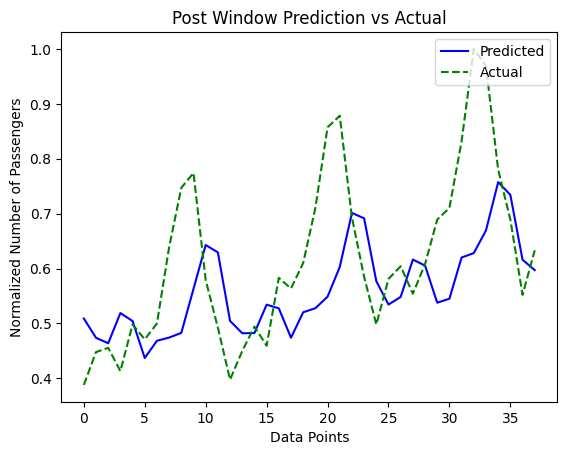

In [35]:
# Visualisasi Hasil Prediksi pada Data Test dan Nilai Sebenarnya
plt.plot(testPredict_post, 'b-', label='Predicted')
plt.plot(testY_post, 'g--', label='Actual')
plt.xlabel('Data Points')
plt.ylabel('Normalized Number of Passengers')
plt.legend(loc='upper right')
plt.title('Post Window Prediction vs Actual')
plt.show()

In [36]:
# Perhitungan RMSE (Root Mean Square Error) pada hasil prediksi
testScore = math.sqrt(mean_squared_error(testY_post, testPredict_post))
print('Test Score: %.2f RMSE' % (testScore))

Test Score: 0.14 RMSE


## Kesimpulan

Dari hasil RMSE 0.14 yang ditunjukan, dapat diketahui jika menggunakan window berukuran 3 (t+2 sebagai target, dan t-4, t-2, t sebagai data latih) ternyata hasilnya tdak lebih baik dari pada menggunakan window berukuran 1 (RMSE 0.09) maupun berukuran 4 (RMSE 0.10). Maka perlu penyusaian window, parameter serta aspek lainnya untuk mendapatkan hasil terbaik. Kemudian dari hasil visualisasi, dapat dilihat bahwa data prediksi cukup besar melesetnya pada model post test jika dibanding pada model langkah praktikum.